# COMP20008 Assignment 2 (W06G02) Code

**How to run.** Put the Inside Airbnb Melbourne `listings.csv` in `data/` next to this notebook, then *Kernel → Restart & Run All*. See `README.md` for more details such as requirements and runtime.

Every number cited in the report is written to an `outputs/evidence_*.json` file by the part that computes it.

## Part 0: Setup

In [ ]:
import json
import os
import pathlib
import platform
from itertools import combinations

import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy
import seaborn as sns
import sklearn
from matplotlib.patches import Patch
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import AgglomerativeClustering, KMeans
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA
from sklearn.dummy import DummyClassifier
from sklearn.feature_selection import mutual_info_classif
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    classification_report,
    confusion_matrix,
    f1_score,
    mutual_info_score,
    normalized_mutual_info_score,
)
from sklearn.model_selection import StratifiedGroupKFold, cross_val_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier

# Paths: the notebook's own folder is the project root. Input: data/listings.csv.
# Every table, figure and evidence file is written to outputs/.
PROJECT_ROOT = pathlib.Path().resolve()
DATA_DIR = PROJECT_ROOT / "data"
OUTPUT_DIR = PROJECT_ROOT / "outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

DEFAULT_ROUNDING_DECIMALS = 4
# One seed for every random step (split, CV shuffling, tree ties, bootstrap, permutation,
# K-Means, sampling) so that a full re-run reproduces every number in the report.
RANDOM_SEED = 20008


# Utility function used to round a value to a given number of places
def round_value(value, digits=DEFAULT_ROUNDING_DECIMALS):
    return round(float(value), digits)


# Library versions used to produce the reported results
# Mentioned in README to ensure consistency
print(
    f"Python {platform.python_version()} | pandas {pd.__version__} | numpy {np.__version__} | "
    f"scikit-learn {sklearn.__version__} | scipy {scipy.__version__} | matplotlib {matplotlib.__version__} | seaborn {sns.__version__}"
)

mkdir -p failed for path /Users/leoo/.matplotlib: [Errno 1] Operation not permitted: '/Users/leoo/.matplotlib'
Matplotlib created a temporary cache directory at /var/folders/xk/j47t3rp17776zyd3t1dftcsc0000gn/T/matplotlib-i_7mes3n because there was an issue with the default path (/Users/leoo/.matplotlib); it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.
Matplotlib is building the font cache; this may take a moment.


Python 3.13.2 | pandas 3.0.5 | numpy 2.5.3 | scikit-learn 1.9.1 | scipy 1.18.1 | matplotlib 3.11.2 | seaborn 0.13.2


## Part 1: Preprocessing

Input: `data/listings.csv` (Inside Airbnb, 25,728 rows).  
Outputs: 
- `data/clean.parquet` (all rows, with the new columns)
- `outputs/evidence_preprocess.json`

In [ ]:
CBD_LOCATION = (-37.8183, 144.9671)  # Flinders Street Station in the format (latitude, longitude)
CLEANED_DATA_FILENAME = "clean.parquet"
EVIDENCE_FILENAME = "evidence_preprocess.json"

# Listings dataframe
listings = pd.read_csv(DATA_DIR / "listings.csv")

# Evidence dictionary, dumped into outputs/evidence_preprocess.json and cited in the report.
evidence = {"row_count": len(listings), "host_count": listings["host_id"].nunique()}

### 1.1 Parsing text into numbers

In [ ]:
# Price parsing
# Strip '$' and the thousands separator, then cast to float. 
listings["price_num"] = listings["price"].str.replace(r"[$,]", "", regex=True).astype(float)

# Amenity count parsing
# json.loads rather than splitting on commas as some amenity names contain a comma
listings["amenity_count"] = listings["amenities"].apply(lambda raw_json: len(json.loads(raw_json)))

# Target variable 'y' (whether host is a superhost) parsing.
# Binary: 1 is yes, 0 is no
listings["y"] = (listings["host_is_superhost"] == "t").astype(int)
evidence["superhost_share_overall"] = round_value(listings["y"].mean())
is_superhost = listings["y"] == 1

# One host has many listings. Calculate evidence regarding
# the number of listings that are under multihosts to help
# determine how the data should be split.
listings_per_host = listings.groupby("host_id").size()
evidence["multi_listing_host_listing_share"] = round_value(listings_per_host[listings_per_host > 1].sum() / len(listings))

### 1.2 Calculating days since last review and handling zero-review listings

In [4]:
# Handling 'days since last review' column
last_review_date = pd.to_datetime(listings["last_review"], errors="coerce")  # 'coerce' is used to suppress NaN parsing errors
# has_review must be created BEFORE the fill below: once filled, the originally
# missing rows can no longer be told apart from real values.
listings["has_review"] = last_review_date.notna().astype(int)
has_review_bool = listings["has_review"] == 1
# Reference date = the latest last_review in the snapshot, not today's date, so the
# feature is identical on every run (the dataset is a fixed scrape).
days_since_review = (last_review_date.max() - last_review_date).dt.days

# Update evidence with relevant information
evidence.update(
    {
        # A reference date that the statistics are based on
        "reference_date": str(last_review_date.max().date()),
        # Describing 'Date since last review' data distribution
        "days_since_last_review_median": round_value(days_since_review[has_review_bool].median()),
        "days_since_last_review_max": int(days_since_review.max()),
        # Size of the zero-review group
        "zero_review_count": int((~has_review_bool).sum()),
        "zero_review_pct": round_value((~has_review_bool).mean() * 100, 2),
        # Calculate superhost status within the zero-review group
        # to determine whether we can drop the relevant rows or not
        "superhost_share_no_review": round_value(listings.loc[~has_review_bool, "y"].mean()),
        "superhost_share_has_review": round_value(listings.loc[has_review_bool, "y"].mean()),
        "superhost_count_no_review": int((~has_review_bool & is_superhost).sum()),
        # Days since last review (with reference date) v.s. the feature 'number_of_reviews_ltm'
        # which is the number of reviews in the last 12 months
        "days_since_last_review_vs_reviews_ltm_spearman": round_value(days_since_review[has_review_bool].corr(listings.loc[has_review_bool, "number_of_reviews_ltm"], method="spearman")),
    }
)

# Imputation value for zero-review listings: max + 1 = "longer ago than any reviewed
# listing". The median (84 days) would say the opposite (recently active). The
# has_review flag tells the models which values are filled.
evidence["days_since_last_review_fill_value"] = evidence["days_since_last_review_max"] + 1
listings["days_since_last_review"] = days_since_review.fillna(evidence["days_since_last_review_fill_value"])

### 1.3 Amenity count

In [5]:
# Naive comma-split count (the Assignment 1 method). It is NOT used as a feature; it is
# kept only to measure the before/after impact of the json.loads fix in Section 1.
def count_amenities_naive(amenities: str):
    if pd.isna(amenities):
        return 0
    text = amenities.strip()
    if text.startswith("[") and text.endswith("]"):
        text = text[1:-1]
    if text == "":
        return 0
    return len(text.split(","))


naive_amenity_count = listings["amenities"].apply(count_amenities_naive)
amenity_count_differs = naive_amenity_count != listings["amenity_count"]


evidence.update(
    {
        "amenity_naive_diff_count": int(amenity_count_differs.sum()),
        "amenity_naive_diff_pct": round_value(amenity_count_differs.mean() * 100, 2),
        "amenity_naive_max_diff": int((naive_amenity_count - listings["amenity_count"]).abs().max()),
        "amenity_zero_count": int((listings["amenity_count"] == 0).sum()),
        "amenity_zero_pct": round_value((listings["amenity_count"] == 0).mean() * 100, 2),
        "amenity_count_mean_superhost": round_value(listings.loc[is_superhost, "amenity_count"].mean(), 2),
        "amenity_count_mean_nonsuperhost": round_value(listings.loc[~is_superhost, "amenity_count"].mean(), 2),
    }
)

### 1.4 Missing prices

In [6]:
price_is_missing = listings["price_num"].isna()
is_unavailable_all_year = listings["availability_365"] == 0

evidence.update(
    {
        "price_missing_count": int(price_is_missing.sum()),
        "price_missing_pct": round_value(price_is_missing.mean() * 100, 2),
        "p_price_missing_given_unavailable": round_value(price_is_missing[is_unavailable_all_year].mean()),
        "p_price_missing_given_available": round_value(price_is_missing[~is_unavailable_all_year].mean()),
        "p_unavailable_given_price_missing": round_value(is_unavailable_all_year[price_is_missing].mean()),
        "superhost_share_unavailable": round_value(listings.loc[is_unavailable_all_year, "y"].mean()),
        "superhost_share_available": round_value(listings.loc[~is_unavailable_all_year, "y"].mean()),
    }
)

# Missing-price indicator: price is missing for 99.85% of listings with zero availability,
# so the fact that it is missing carries information that the imputed value hides.
listings["price_missing"] = price_is_missing.astype(int)

### 1.5 Distance to the CBD

In [7]:
# Planar approximation of the distance to Flinders Street Station (km): one degree of
# latitude is about 111 km, and a degree of longitude shrinks by cos(latitude). The error
# is negligible at metropolitan scale. This is a derived feature, not one of the three
# assessed preprocessing steps.
north_south_km = (listings["latitude"] - CBD_LOCATION[0]) * 111
east_west_km = (listings["longitude"] - CBD_LOCATION[1]) * 111 * np.cos(np.radians(CBD_LOCATION[0]))
listings["dist_cbd"] = np.sqrt(north_south_km**2 + east_west_km**2)

### 1.6 Evidence for rejected candidate steps

In [8]:
bedrooms_is_missing = listings["bedrooms"].isna()
property_type_counts = listings["property_type"].value_counts()
# These three candidate steps were NOT implemented. This cell only computes the numbers
# the report uses to justify rejecting them; no column is modified.
evidence.update(
    {
        "bedrooms_missing_pct": round_value(bedrooms_is_missing.mean() * 100, 2),
        "beds_missing_pct": round_value(listings["beds"].isna().mean() * 100, 2),
        "bedrooms_missing_share_by_room_type": bedrooms_is_missing.groupby(listings["room_type"]).mean().round(4).to_dict(),
        "property_type_category_count": len(property_type_counts),
        "property_type_under_10_count": int((property_type_counts < 10).sum()),
        "property_type_rare_row_count": int(property_type_counts[property_type_counts < 10].sum()),
        "property_type_rare_row_pct": round_value(property_type_counts[property_type_counts < 10].sum() / len(listings) * 100, 2),
        "min_nights_ge30_count": int((listings["minimum_nights"] >= 30).sum()),
        "min_nights_ge30_pct": round_value((listings["minimum_nights"] >= 30).mean() * 100, 2),
    }
)

### 1.6b Further evidence cited in the report

In [9]:
# The label belongs to the HOST: every listing of a host carries the same value of y.
# Counting hosts rather than listings gives the host-level superhost rate.
host_labels = listings.groupby("host_id")["y"].first()
evidence.update(
    {
        "superhost_host_count": int(host_labels.sum()),
        "superhost_host_share": round_value(host_labels.mean()),
        # host_listings_count is Airbnb's platform-wide count; this is the largest host
        # measured by rows actually present in this dataset
        "host_listings_count_max": int(listings["host_listings_count"].max()),
        "largest_host_listing_count_in_data": int(listings_per_host.max()),
        # Positive rate if the rows with a missing price were deleted instead of imputed
        "superhost_share_if_price_missing_dropped": round_value(listings.loc[~price_is_missing, "y"].mean()),
        # Shared room + Hotel room, merged into "Other" (room_type_3) in Part 3
        "other_room_type_count": int(listings["room_type"].isin(["Shared room", "Hotel room"]).sum()),
        # Price rises with capacity, the argument for price sitting near the fundamentals
        # (report Section 2.3); measured on the listings whose price is observed, not imputed
        "price_accommodates_spearman": round_value(listings.loc[~price_is_missing, "price_num"].corr(listings.loc[~price_is_missing, "accommodates"], method="spearman")),
    }
)
{
    key: evidence[key]
    for key in (
        "superhost_host_count",
        "superhost_host_share",
        "host_listings_count_max",
        "largest_host_listing_count_in_data",
        "superhost_share_if_price_missing_dropped",
        "other_room_type_count",
        "price_accommodates_spearman",
    )
}

{'superhost_host_count': 3770,
 'superhost_host_share': 0.2671,
 'host_listings_count_max': 667,
 'largest_host_listing_count_in_data': 319,
 'superhost_share_if_price_missing_dropped': 0.3806,
 'other_room_type_count': 283,
 'price_accommodates_spearman': 0.6821}

### 1.7 Checking data and exporting

In [10]:
# Row count should not have changed
assert len(listings) == evidence["row_count"]
# At most one distinct 'y' value per host
assert listings.groupby("host_id")["y"].nunique().max() == 1
# No nulls left in day counts
assert listings[["days_since_last_review"]].notna().all().all()

# Save data
listings.to_parquet(PROJECT_ROOT / "data" / CLEANED_DATA_FILENAME, index=False)
os.makedirs(PROJECT_ROOT / "outputs", exist_ok=True)
with open(PROJECT_ROOT / "outputs" / EVIDENCE_FILENAME, "w") as evidence_file:
    json.dump(evidence, evidence_file, indent=2, ensure_ascii=False, default=int)

## Part 2: Correlation analysis

Input: `data/clean.parquet` (reviewed listings only).  
Outputs: `outputs/correlation_matrix.csv`, `outputs/fig_hlc_vs_y.png`, `outputs/fig_dsl_vs_dist.png`, `outputs/evidence_correlation.json`.

In [11]:
CORRELATION_VARIABLES = ["host_listings_count", "days_since_last_review", "availability_365", "dist_cbd", "y"]

# Each part reloads clean.parquet, so the row filter below cannot leak into Parts 3 and 4.
listings = pd.read_parquet(DATA_DIR / "clean.parquet")
# Reviewed listings only (21,251 rows): the 4,477 zero-review listings all carry the
# artificial fill value 4,594 for days_since_last_review, which would distort every
# coefficient involving that variable.
listings = listings[listings["has_review"] == 1]


# Helper function that discretizes a continuous feature into
# discrete equal-frequency bins
def equal_frequency_bin(column, n_bins=10):
    # If the column is not continuous ('y' is already 0/1) don't do anything
    if column.nunique() <= 2:
        return column
    else:
        # Cut the data into 'n_bins' bins
        # duplicates="drop" merges repeated bin edges: 21.8% of availability_365 is
        # exactly 0, so equal-frequency edges collide and fewer bins are returned
        # (the actual bin counts are recorded in the "bins" column of the table).
        # labels=False returns bin numbers 0,1,2,...
        return pd.qcut(column, n_bins, labels=False, duplicates="drop")


# Note: sklearn's mutual_info_score uses the natural logarithm, so MI is in nats.
evidence = {"n_rows": len(listings)}

### 2.1 Evidence for binning decisions

In [12]:
# Distribution data for methodology
evidence["percentiles"] = listings[["host_listings_count", "days_since_last_review"]].quantile([0.5, 1.0]).to_dict()
evidence["av365_share_0"] = round_value((listings["availability_365"] == 0).mean())
evidence["av365_share_365"] = round_value((listings["availability_365"] == 365).mean())

# Why we use equal frequency rather than equal width
evidence["hlc_equal_width_max_bin"] = {n_bins: round_value(pd.cut(listings["host_listings_count"], n_bins).value_counts(normalize=True).max()) for n_bins in (10, 20)}

# Why we only compare NMI across pairs
dsl_column, availability_column = listings["days_since_last_review"], listings["availability_365"]
evidence["mi_bin_sensitivity"] = {
    n_bins: {
        "mi": round_value(mutual_info_score(equal_frequency_bin(dsl_column, n_bins), equal_frequency_bin(availability_column, n_bins))),
        "nmi": round_value(normalized_mutual_info_score(equal_frequency_bin(dsl_column, n_bins), equal_frequency_bin(availability_column, n_bins))),
    }
    for n_bins in (5, 10, 20)
}

evidence

{'n_rows': 21251,
 'percentiles': {'host_listings_count': {0.5: 2.0, 1.0: 667.0},
  'days_since_last_review': {0.5: 84.0, 1.0: 4593.0}},
 'av365_share_0': 0.2176,
 'av365_share_365': 0.0156,
 'hlc_equal_width_max_bin': {10: 0.9143, 20: 0.8456},
 'mi_bin_sensitivity': {5: {'mi': 0.1175, 'nmi': 0.0799},
  10: {'mi': 0.1829, 'nmi': 0.0856},
  20: {'mi': 0.2499, 'nmi': 0.0896}}}

### 2.2 Correlation table (5 variables, 10 pairs, 4 measures)

In [13]:
table_rows = []
for variable_a, variable_b in combinations(CORRELATION_VARIABLES, 2):
    binned_a, binned_b = equal_frequency_bin(listings[variable_a]), equal_frequency_bin(listings[variable_b])
    table_rows.append(
        {
            "pair": f"{variable_a} ~ {variable_b}",
            # Pearson with the 0/1 target is the point-biserial correlation: valid, but it
            # only captures a difference in means (a linear trend), not the shape.
            # Spearman works on ranks, so it is robust to the long tails here but still
            # assumes a monotonic relationship. MI/NMI need discrete inputs, so continuous
            # variables are binned first; y is already discrete and is used as is.
            "pearson": round_value(listings[variable_a].corr(listings[variable_b]), 3),
            "spearman": round_value(listings[variable_a].corr(listings[variable_b], method="spearman"), 3),
            "mi": round_value(mutual_info_score(binned_a, binned_b)),
            # mutual_info_score uses the natural log (nats); the lectures use log2 (bits).
            # bits = nats / ln 2. NMI is unit-free, so it is the same in either unit.
            "mi_bits": round_value(mutual_info_score(binned_a, binned_b) / np.log(2)),
            "nmi": round_value(normalized_mutual_info_score(binned_a, binned_b)),
            "bins": f"{binned_a.nunique()}×{binned_b.nunique()}",
        }
    )

# Sort table by NMI descending
correlation_table = pd.DataFrame(table_rows).sort_values("nmi", ascending=False)

correlation_table

,pair,pearson,spearman,mi,mi_bits,nmi,bins
4,days_since_last_review ~ availability_365,-0.438,-0.395,0.1829,0.2639,0.0856,10×8
6,days_since_last_review ~ y,-0.337,-0.443,0.1159,0.1672,0.0785,10×2
8,availability_365 ~ y,0.146,0.155,0.0425,0.0613,0.0324,8×2
2,host_listings_count ~ dist_cbd,-0.131,-0.225,0.0580,0.0837,0.0285,7×10
0,host_listings_count ~ days_since_last_review,-0.113,-0.194,0.0558,0.0806,0.0274,7×10
1,host_listings_count ~ availability_365,0.059,0.225,0.0430,0.0621,0.0230,7×8
7,availability_365 ~ dist_cbd,0.170,0.124,0.0315,0.0455,0.0147,8×10
5,days_since_last_review ~ dist_cbd,-0.081,0.061,0.0317,0.0458,0.0138,10×10
3,host_listings_count ~ y,-0.069,0.070,0.0117,0.0169,0.0097,7×2
9,dist_cbd ~ y,0.076,0.009,0.0070,0.0101,0.0047,10×2


### 2.3 Finding disagreements between Pearson and Spearman

In [14]:
# Pearson & Spearman having opposite signs:
evidence["sign_flip_pairs"] = correlation_table.loc[correlation_table["pearson"] * correlation_table["spearman"] < 0, "pair"].tolist()

evidence["sign_flip_pairs"]

['days_since_last_review ~ dist_cbd', 'host_listings_count ~ y']

### 2.4 Host scale vs superhost rate

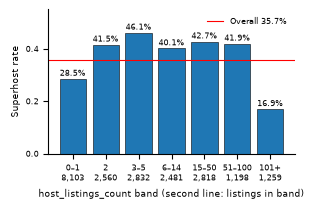

In [15]:
overall_superhost_rate = listings["y"].mean()
host_size_bands = listings.groupby(pd.cut(listings["host_listings_count"], [0, 1, 2, 5, 14, 50, 100, 700], include_lowest=True), observed=True)["y"].agg(n="size", rate="mean")
host_size_bands.index = host_size_bands.index.astype(str)
evidence["hlc_band"] = host_size_bands.round(DEFAULT_ROUNDING_DECIMALS).to_dict()

# Figure drawing, sized for the report: 2.9 x 1.95 inches inserted at 100%, so the
# 6-7 pt labels print at that size (the caption carries the title)
with plt.rc_context({"font.size": 6.5, "axes.labelsize": 6.5, "xtick.labelsize": 6, "ytick.labelsize": 6}):
    figure, axis = plt.subplots(figsize=(2.9, 1.95))
    axis.bar(range(len(host_size_bands)), host_size_bands["rate"], edgecolor="black", linewidth=0.4)
    axis.axhline(overall_superhost_rate, color="red", linewidth=0.8, label=f"Overall {overall_superhost_rate:.1%}")
    for bar_position, band_rate in enumerate(host_size_bands["rate"]):
        axis.text(bar_position, band_rate + 0.012, f"{band_rate:.1%}", ha="center", fontsize=6)
    axis.set_xticks(range(len(host_size_bands)))
    # Readable band names for the bins (0,1], (1,2], (2,5], (5,14], (14,50], (50,100], (100,700]
    BAND_LABELS = ["0–1", "2", "3–5", "6–14", "15–50", "51–100", "101+"]
    assert len(BAND_LABELS) == len(host_size_bands)
    axis.set_xticklabels([f"{band}\n{count:,}" for band, count in zip(BAND_LABELS, host_size_bands["n"])])
    axis.set(ylim=(0, 0.55), xlabel="host_listings_count band (second line: listings in band)", ylabel="Superhost rate")
    axis.legend(loc="upper right", fontsize=6, frameon=False)
    axis.spines[["top", "right"]].set_visible(False)
    plt.tight_layout(pad=0.3)
    plt.savefig(OUTPUT_DIR / "fig_hlc_vs_y.png", dpi=300)
    plt.close(figure)

figure

### 2.5 Review recency by distance band

             n  dist_km  dsl_median
dist_cbd                           
0         1063     0.61        60.0
1         1065     0.93        43.0
2         1060     1.13        44.0
3         1063     1.24        41.0
4         1062     1.36        51.0
5         1063     1.71       111.0
6         1062     2.20       103.0
7         1063     2.64       109.0
8         1062     3.40       111.5
9         1063     4.23       115.0
10        1062     5.04       122.0
11        1063     5.93       112.0
12        1062     7.15       111.0
13        1063     8.97       111.0
14        1062    12.17       107.5
15        1063    15.15        91.0
16        1062    18.95       110.5
17        1063    25.17       103.0
18        1062    34.65        69.0
19        1063    50.64        47.0


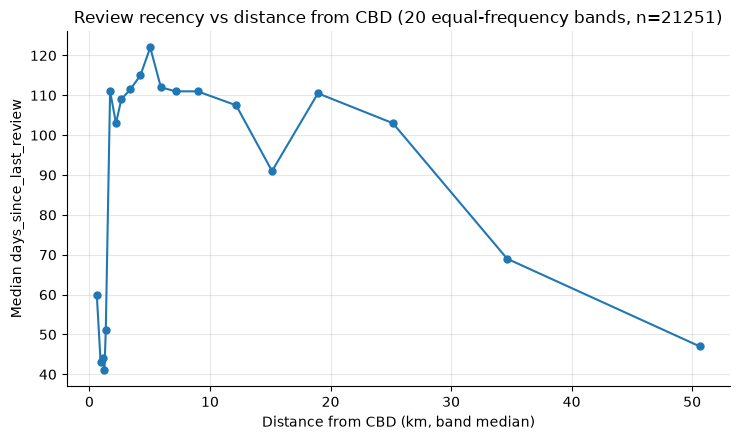

In [16]:
# Pearson (-0.081) and Spearman (+0.061) disagree in sign for
# days_since_last_review ~ dist_cbd. Banding distance into 20 equal-frequency groups
# (about 1,060 listings each) shows the shape behind the disagreement: a non-monotonic
# pattern that neither a linear nor a rank coefficient can summarise in one number.
distance_trend = listings.groupby(pd.qcut(listings["dist_cbd"], 20, labels=False)).agg(
    n=("dist_cbd", "size"),
    dist_km=("dist_cbd", "median"),
    # Median rather than mean: days_since_last_review reaches 4,593
    dsl_median=("days_since_last_review", "median"),
)
evidence["dist_band_trend"] = distance_trend.round(2).to_dict("index")

figure, axis = plt.subplots(figsize=(7.5, 4.5))
axis.plot(distance_trend["dist_km"], distance_trend["dsl_median"], marker="o", linewidth=1.5, markersize=5)
axis.set(
    xlabel="Distance from CBD (km, band median)",
    ylabel="Median days_since_last_review",
    title=f"Review recency vs distance from CBD (20 equal-frequency bands, n={len(listings)})",
)
axis.grid(alpha=0.3)
axis.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "fig_dsl_vs_dist.png", dpi=150)
plt.close(figure)

print(distance_trend.round(2).to_string())
figure

### 2.6 Save

In [17]:
# Save correlation matrix CSV
correlation_table.to_csv(os.path.join(OUTPUT_DIR, "correlation_matrix.csv"), index=False)

# Save evidence JSON
with open(os.path.join(OUTPUT_DIR, "evidence_correlation.json"), "w") as evidence_file:
    json.dump(evidence, evidence_file, indent=2, ensure_ascii=False, default=str)

print(correlation_table.to_string(index=False))

                                        pair  pearson  spearman     mi  mi_bits    nmi  bins
   days_since_last_review ~ availability_365   -0.438    -0.395 0.1829   0.2639 0.0856  10×8
                  days_since_last_review ~ y   -0.337    -0.443 0.1159   0.1672 0.0785  10×2
                        availability_365 ~ y    0.146     0.155 0.0425   0.0613 0.0324   8×2
              host_listings_count ~ dist_cbd   -0.131    -0.225 0.0580   0.0837 0.0285  7×10
host_listings_count ~ days_since_last_review   -0.113    -0.194 0.0558   0.0806 0.0274  7×10
      host_listings_count ~ availability_365    0.059     0.225 0.0430   0.0621 0.0230   7×8
                 availability_365 ~ dist_cbd    0.170     0.124 0.0315   0.0455 0.0147  8×10
           days_since_last_review ~ dist_cbd   -0.081     0.061 0.0317   0.0458 0.0138 10×10
                     host_listings_count ~ y   -0.069     0.070 0.0117   0.0169 0.0097   7×2
                                dist_cbd ~ y    0.076     0.009 0.0070

## Part 3: Supervised learning and feature selection

Input: `data/clean.parquet` (all 25,728 rows).  
Outputs: `outputs/evidence_model.json`, `outputs/cv_results.csv`, `outputs/rq_experiments.csv`, `outputs/rq_experiments_extra.csv`, `outputs/feature_ranking.csv`, `outputs/fig_confusion.png`, `outputs/fig_importance.png`.

In [18]:
evidence = {}

# Listings dataframe (reloaded: all rows, including zero-review listings)
listings = pd.read_parquet(DATA_DIR / "clean.parquet")
# Shared room (n=231) and Hotel room (n=52) are merged into "Other": one-hot columns that are
# almost all zero would leave only a few dozen positives per CV fold.
listings["room_type_3"] = listings["room_type"].replace({"Shared room": "Other", "Hotel room": "Other"})

fundamentals = ["room_type_3", "dist_cbd", "accommodates"]
operationals = ["availability_365", "amenity_count", "days_since_last_review", "has_review", "price_num", "price_missing", "minimum_nights", "host_listings_count"]
# Whitelist of the 11 model features. Airbnb's own superhost criteria (review_scores_*,
# number_of_reviews, reviews_per_month, ...) are excluded simply by not being listed.
# price_num (with NaN) is used rather than an imputed price column: filling it beforehand
# would use a median over all rows, including future test rows. The pipeline below
# re-imputes using training data only, which avoids that leakage.
ALL_FEATURES = fundamentals + operationals
X, y, host_ids = listings[ALL_FEATURES], listings["y"], listings["host_id"]

### 3.1 Stratified split by host

In [19]:
# Separate group into 5 folds:
# Stratified: both sides keep the 30.65% superhost rate. Group: all listings of one host
# move together, because the label belongs to the host and 55.8% of listings share a host
# with another listing; a random split would let the model 'recognise' hosts.
group_kfold_splitter = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)
# One fold becomes test set:
train_row_positions, test_row_positions = next(group_kfold_splitter.split(X, y, groups=host_ids))

# Training set and test set separation:
X_train, X_test = (
    X.iloc[train_row_positions],
    X.iloc[test_row_positions],
)
y_train, y_test = y.iloc[train_row_positions], y.iloc[test_row_positions]
host_ids_train, host_ids_test = (
    host_ids.iloc[train_row_positions],
    host_ids.iloc[test_row_positions],
)

evidence["split"] = {
    "train_rows": len(X_train),
    "test_rows": len(X_test),
    "test_share": round_value(len(X_test) / len(X)),
    "train_hosts": int(host_ids_train.nunique()),
    "test_hosts": int(host_ids_test.nunique()),
    "train_pos_rate": round_value(y_train.mean()),
    "test_pos_rate": round_value(y_test.mean()),
    "host_overlap": len(set(host_ids_train) & set(host_ids_test)),
}

# A host must never appear on both sides. The label is a property of the host, so an
# overlap would let the model score by recognising a host it has already seen.
assert evidence["split"]["host_overlap"] == 0, "a host appears on both sides of the split"

print("Split information")
evidence["split"]

Split information


{'train_rows': 20582,
 'test_rows': 5146,
 'test_share': 0.2,
 'train_hosts': 11292,
 'test_hosts': 2821,
 'train_pos_rate': 0.3065,
 'test_pos_rate': 0.3065,
 'host_overlap': 0}

### 3.1b Split and validation details

In [20]:
# Class counts on each side (listings, not hosts), the size of every CV validation fold, and
# why 5 folds rather than 10: the largest host would fill twice the share of a 10-fold
# validation fold, so a single host could dominate that fold's score.
validation_folds = [
    {"rows": len(fold), "superhost_rows": int(y_train.iloc[fold].sum()), "hosts": int(host_ids_train.iloc[fold].nunique())}
    for _, fold in group_kfold_splitter.split(X_train, y_train, groups=host_ids_train)
]
largest_host_rows = int(host_ids.value_counts().max())
evidence["split_details"] = {
    "train_superhost_rows": int(y_train.sum()),
    "train_non_superhost_rows": int((y_train == 0).sum()),
    "test_superhost_rows": int(y_test.sum()),
    "test_non_superhost_rows": int((y_test == 0).sum()),
    "cv_validation_folds": validation_folds,
    "largest_host_rows": largest_host_rows,
    "largest_host_share_of_5fold_validation": round_value(largest_host_rows / (len(X_train) / 5)),
    "largest_host_share_of_10fold_validation": round_value(largest_host_rows / (len(X_train) / 10)),
    # The pipelines impute price_num with the TRAINING median (not the full-data median)
    "price_median_train": round_value(X_train["price_num"].median(), 2),
}
evidence["split_details"]

{'train_superhost_rows': 6308,
 'train_non_superhost_rows': 14274,
 'test_superhost_rows': 1577,
 'test_non_superhost_rows': 3569,
 'cv_validation_folds': [{'rows': 4117, 'superhost_rows': 1262, 'hosts': 2259},
  {'rows': 4116, 'superhost_rows': 1261, 'hosts': 2258},
  {'rows': 4117, 'superhost_rows': 1262, 'hosts': 2258},
  {'rows': 4116, 'superhost_rows': 1262, 'hosts': 2259},
  {'rows': 4116, 'superhost_rows': 1261, 'hosts': 2258}],
 'largest_host_rows': 319,
 'largest_host_share_of_5fold_validation': 0.0775,
 'largest_host_share_of_10fold_validation': 0.155,
 'price_median_train': 245.0}

### 3.2 Pipeline initialisation

In [21]:
def build_preprocessor(feature_list, scale=False):
    """
    Builds a preprocessor for a given column.
    For numeric columns, impute the median using the training dataset
    For room type, the data is one-hot encoded

    Args:
        feature_list: the column data
        scale: Whether to standardise the column or not (using StandardScaler). Defaults to False.

    Returns:
        A sklearn column transformer object
    """

    # Numeric features are all features except for room type
    numeric_features = [column for column in feature_list if column != "room_type_3"]
    numeric_steps = [("impute", SimpleImputer(strategy="median"))]
    if scale:
        numeric_steps.append(("scale", StandardScaler()))
    transformer_branches = [("num", Pipeline(numeric_steps), numeric_features)] if numeric_features else []
    if "room_type_3" in feature_list:
        transformer_branches.append(("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), ["room_type_3"]))
    return ColumnTransformer(transformer_branches)


def build_model(model_name: str, feature_list: list[str], hyperparameter):
    """Builds a model via preprocessor and classifier.

    Args:
        model_name: Either 'KNN' for kNN or 'DT' for decision tree
        feature_list: a string list of features to train on
        hyperparameter: the hyperparameter corresponding to model name.
        - For KNN it is k.
        - For decision tree it is tree depth
    """
    if model_name == "KNN":
        return Pipeline(
            [
                # Requires a scaling step because kNN judges by distance; otherwise
                # days_since_last_review (up to 4,594) would swamp 0/1 columns such as has_review.
                ("prep", build_preprocessor(feature_list, scale=True)),
                ("model", KNeighborsClassifier(n_neighbors=hyperparameter)),
            ]
        )
    elif model_name == "DT":
        return Pipeline(
            [
                (
                    "prep",
                    # No scaling for the tree: splits are thresholds, so rescaling a column
                    # does not change the tree, and unscaled thresholds stay in real units.
                    build_preprocessor(feature_list, scale=False),
                ),
                ("model", DecisionTreeClassifier(max_depth=hyperparameter, random_state=RANDOM_SEED)),
            ]
        )
    else:
        raise Exception("Unknown model type:", model_name)


def cross_validate_f1(model, feature_list: list[str]):
    """
    Runs 5-fold Cross Validation on the training set

    Args:
        model: The model object itself
        feature_list: The list of features

    Returns:
        Five F1 scores
    """

    return cross_val_score(
        model,
        X_train[feature_list],
        y_train,
        # groups must be passed: without it no error is raised, but the CV folds would
        # no longer be split by host.
        groups=host_ids_train,
        cv=group_kfold_splitter,
        scoring="f1",
        n_jobs=-1,
    )

### 3.3 Baseline + Tuning

In [22]:
# Each candidate value gets one 5-fold CV run.
tuning_rows = []

# Baseline scores: model will predict 0 every time
fold_scores = cross_validate_f1(DummyClassifier(strategy="most_frequent"), ALL_FEATURES)
# Append distribution information
tuning_rows.append({"model": "Baseline", "param": "-", "cv_mean": fold_scores.mean(), "cv_std": fold_scores.std()})

HYPERPARAMETER_GRID = {
    # Hyperparamer 'k' for kNN
    "KNN": [1, 5, 11, 21, 51, 101, 151, 201, 301],
    # Hyperparameter tree depth for decision trees
    # None means no limit, ending with a rule per listing (overfit)
    "DT": [2, 3, 4, 5, 6, 8, 10, 15, None],
}

for model_name, candidate_values in HYPERPARAMETER_GRID.items():
    for hyperparameter in candidate_values:
        # Calculate cross validation scores:
        fold_scores = cross_validate_f1(build_model(model_name, ALL_FEATURES, hyperparameter), ALL_FEATURES)
        # Calculate the distribution info of the scores:
        tuning_rows.append({"model": model_name, "param": hyperparameter, "cv_mean": fold_scores.mean(), "cv_std": fold_scores.std()})

# This table reports every candidates cross validation score
tuning_table = pd.DataFrame(tuning_rows)

# Find the best hyperparameter of each model by CV mean (read from the list of dicts, not
# the DataFrame: pandas would turn the int/None column into floats, e.g. n_neighbors=101.0)
best_hyperparameters = {}
best_cv_by_model = {}
for model_name in HYPERPARAMETER_GRID:
    model_rows = [row for row in tuning_rows if row["model"] == model_name]
    best_row = max(model_rows, key=lambda row: row["cv_mean"])
    best_hyperparameters[model_name] = best_row["param"]
    best_cv_by_model[model_name] = best_row["cv_mean"]

# The better model is the one with the higher best CV score; the test set is not consulted.
best_model_name = max(best_cv_by_model, key=best_cv_by_model.get)
evidence["best_param"], evidence["best_model"] = best_hyperparameters, best_model_name
print(tuning_table.round(4).to_string(index=False))
print("Best model:", best_model_name)
print("Best hyperparameters:")
best_hyperparameters

   model param  cv_mean  cv_std
Baseline     -   0.0000  0.0000
     KNN     1   0.4802  0.0175
     KNN     5   0.5020  0.0159
     KNN    11   0.5071  0.0176
     KNN    21   0.5190  0.0112
     KNN    51   0.5299  0.0121
     KNN   101   0.5370  0.0133
     KNN   151   0.5312  0.0147
     KNN   201   0.5309  0.0175
     KNN   301   0.5249  0.0226
      DT     2   0.5158  0.0503
      DT     3   0.5611  0.0431
      DT     4   0.5712  0.0177
      DT     5   0.5384  0.0424
      DT     6   0.5512  0.0240
      DT     8   0.5622  0.0123
      DT    10   0.5745  0.0130
      DT    15   0.5363  0.0171
      DT  None   0.5018  0.0072
Best model: DT
Best hyperparameters:


{'KNN': 101, 'DT': 10}

### 3.4 Final test-set evaluation


==== Baseline ====
              precision    recall  f1-score   support

           0      0.694     1.000     0.819      3569
           1      0.000     0.000     0.000      1577

    accuracy                          0.694      5146
   macro avg      0.347     0.500     0.410      5146
weighted avg      0.481     0.694     0.568      5146


==== KNN ====
              precision    recall  f1-score   support

           0      0.811     0.832     0.821      3569
           1      0.596     0.560     0.577      1577

    accuracy                          0.749      5146
   macro avg      0.703     0.696     0.699      5146
weighted avg      0.745     0.749     0.746      5146


==== DT ====
              precision    recall  f1-score   support

           0      0.845     0.807     0.825      3569
           1      0.603     0.664     0.632      1577

    accuracy                          0.763      5146
   macro avg      0.724     0.735     0.729      5146
weighted avg      0.770  

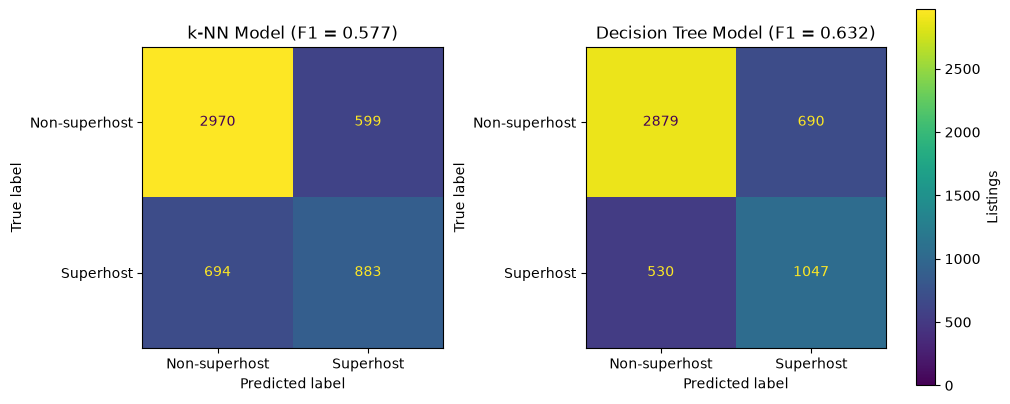

In [ ]:
# Best models with specified best hyperparameters
final_models = {
    "Baseline": DummyClassifier(strategy="most_frequent"),
    "KNN": build_model("KNN", ALL_FEATURES, best_hyperparameters["KNN"]),
    "DT": build_model("DT", ALL_FEATURES, best_hyperparameters["DT"]),
}

# Test set predictions
test_predictions = {}
# Test prediction metrics (f1 and accuracy)
evidence["test"] = {}

for model_name, model in final_models.items():
    # Train the model on the given data:
    test_predictions[model_name] = model.fit(X_train, y_train).predict(X_test)
    report = classification_report(y_test, test_predictions[model_name], digits=3, zero_division=0, output_dict=True)

    # Build the base metrics
    model_evidence = {
        "f1": round_value(report["1"]["f1-score"]),
        "accuracy": round_value(report["accuracy"]),
    }

    # Add per-class metrics
    for label in ("0", "1"):
        model_evidence[f"class_{label}"] = {metric: round_value(report[label][metric]) for metric in ("precision", "recall", "f1-score")}

    evidence["test"][model_name] = model_evidence

    print(f"\n==== {model_name} ====")
    print(classification_report(y_test, test_predictions[model_name], digits=3, zero_division=0))

# Generate kNN and DT confusion matrices
confusion_matrices = {model_name: confusion_matrix(y_test, test_predictions[model_name]) for model_name in ("KNN", "DT")}
shared_max = max(matrix.max() for matrix in confusion_matrices.values())

figure, axes = plt.subplots(1, 2, figsize=(10, 4), layout="constrained")
model_name_formatted = {"KNN": "k-NN Model", "DT": "Decision Tree Model"}
for axis, model_name in zip(axes, ["KNN", "DT"]):
    ConfusionMatrixDisplay.from_predictions(y_test, test_predictions[model_name], ax=axis, colorbar=False, display_labels=["Non-superhost", "Superhost"], im_kw={"vmin": 0, "vmax": shared_max})
    axis.set_title(f"{model_name_formatted[model_name]} (F1 = {evidence['test'][model_name]['f1']:.3f})")  # ty:ignore[not-subscriptable]
figure.colorbar(axes[1].images[0], ax=axes, fraction=0.046, pad=0.04, label="Listings")
plt.savefig(os.path.join(OUTPUT_DIR, "fig_confusion.png"), dpi=150, bbox_inches="tight")
plt.close(figure)

y_test_array = y_test.to_numpy()
test_rows_by_host = list(host_ids_test.reset_index(drop=True).groupby(host_ids_test.to_numpy()).indices.values())


# Paired bootstrap comparison
def bootstrap_compare(predictions_a, predictions_b, n_resamples=1000):
    """
    Compare two models with bootstraping.

    Resamples the hosts with replacement n_resamples times, scoring both
    models on each identical resample, and returns the 95% percentile interval for
    each model's F1 score.
    """
    rng = np.random.default_rng(RANDOM_SEED)
    scores_a, scores_b = [], []
    for _ in range(n_resamples):
        sampled_hosts = rng.integers(len(test_rows_by_host), size=len(test_rows_by_host))
        sampled_rows = np.concatenate([test_rows_by_host[host] for host in sampled_hosts])
        scores_a.append(f1_score(y_test_array[sampled_rows], predictions_a[sampled_rows]))
        scores_b.append(f1_score(y_test_array[sampled_rows], predictions_b[sampled_rows]))

    def confidence_interval(scores):
        # Generate a confidence 95% interval from the provided argument
        return [round_value(bound) for bound in np.percentile(scores, [2.5, 97.5])]

    return {
        "a": confidence_interval(scores_a),
        "b": confidence_interval(scores_b),
        "b_minus_a": confidence_interval(np.array(scores_b) - np.array(scores_a)),
    }


evidence["boot_KNN_vs_DT"] = bootstrap_compare(test_predictions["KNN"], test_predictions["DT"])
# Printed explicitly: a bare expression in the middle of a cell is not displayed.
print("\nbootstrap KNN vs DT:", evidence["boot_KNN_vs_DT"])
figure

### 3.4b Further test-set metrics

In [ ]:
# Metrics for this section: macro-F1 (both classes weighted equally), training-set F1
# (a large train-test gap signals overfitting), confusion-matrix counts, and the absolute
# improvement of each model over the majority-class baseline on the same metrics.
evidence["test_extra"] = {}
for model_name, model in final_models.items():
    tn, fp, fn, tp = confusion_matrix(y_test, test_predictions[model_name]).ravel()
    evidence["test_extra"][model_name] = {
        "macro_f1": round_value(f1_score(y_test, test_predictions[model_name], average="macro")),
        "train_f1": round_value(f1_score(y_train, model.predict(X_train), zero_division=0)),
        "true_positive": int(tp),
        "false_positive": int(fp),
        "false_negative": int(fn),
        "true_negative": int(tn),
        "predicted_superhost": int(tp + fp),
    }
for model_name in ("KNN", "DT"):
    evidence["test_extra"][model_name]["gain_over_baseline"] = {
        "f1": round_value(evidence["test"][model_name]["f1"] - evidence["test"]["Baseline"]["f1"]),
        "accuracy": round_value(evidence["test"][model_name]["accuracy"] - evidence["test"]["Baseline"]["accuracy"]),
        "macro_f1": round_value(evidence["test_extra"][model_name]["macro_f1"] - evidence["test_extra"]["Baseline"]["macro_f1"]),
    }
pd.DataFrame(evidence["test_extra"]).T

,macro_f1,train_f1,true_positive,false_positive,false_negative,true_negative,predicted_superhost,gain_over_baseline
Baseline,0.4095,0.0,0.0,0.0,1577.0,3569.0,0.0,NaN
KNN,0.6993,0.6023,883,599,694,2970,1482,"{'f1': 0.5773, 'accuracy': 0.0552, 'macro_f1':..."
DT,0.7285,0.7188,1047,690,530,2879,1737,"{'f1': 0.6319, 'accuracy': 0.0694, 'macro_f1':..."


### 3.5 Feature-set experiments

Shows model only part of the features and sees what it scores.

In [ ]:
REVIEW_FEATURES = [
    "days_since_last_review",
    "has_review",
]
FEATURE_SETS = {
    # Fundamentals only
    "A_fundamentals": fundamentals,
    # Operational only
    "B_operational": operationals,
    # Control group: All features, identical to our final model
    "C_all": ALL_FEATURES,
    # All features except days_since_last_review and has_review
    # Determines whether review recency has any relevance
    "D_all_no_review": [column for column in ALL_FEATURES if column not in REVIEW_FEATURES],
    # All features except availability_365
    "E_all_no_avail": [column for column in ALL_FEATURES if column != "availability_365"],
    # Operational only except days_since_last_review and has_review
    "F_operational_no_review": [column for column in operationals if column not in REVIEW_FEATURES],
}


def run_feature_sets(feature_sets):
    """
    For each feature set and each of the two models, calculate:
    - CV score
    - test score
    """
    result_rows, predictions = [], {}
    for experiment_name, feature_list in feature_sets.items():
        for model_name in ("KNN", "DT"):
            # Build model on restricted feature set
            model = build_model(model_name, feature_list, best_hyperparameters[model_name])
            # 5-Fold CV on training set
            fold_scores = cross_validate_f1(model, feature_list)
            # Train and predict
            predictions[experiment_name, model_name] = model.fit(X_train[feature_list], y_train).predict(X_test[feature_list])
            result_rows.append(
                {
                    "experiment": experiment_name,
                    "model": model_name,
                    "n_features": len(feature_list),
                    "cv_mean": fold_scores.mean(),
                    "cv_std": fold_scores.std(),
                    "test_f1": f1_score(y_test, predictions[experiment_name, model_name]),
                }
            )
    return pd.DataFrame(result_rows), predictions


rq_experiment_table, rq_test_predictions = run_feature_sets(FEATURE_SETS)
# Self-check: experiment C uses the same features and hyperparameters as the final models,
# so its test predictions must match Section 4 exactly (guards cross-section consistency).
assert all((rq_test_predictions["C_all", model_name] == test_predictions[model_name]).all() for model_name in ("KNN", "DT"))
evidence["rq"] = rq_experiment_table.round(4).to_dict("records")
evidence["boot_A_vs_B"] = bootstrap_compare(rq_test_predictions["A_fundamentals", best_model_name], rq_test_predictions["B_operational", best_model_name])
evidence["boot_A_vs_F"] = bootstrap_compare(rq_test_predictions["A_fundamentals", best_model_name], rq_test_predictions["F_operational_no_review", best_model_name])

print("\n", rq_experiment_table.pivot(index="experiment", columns="model", values="cv_mean").round(4))
print("A vs B:", evidence["boot_A_vs_B"])
print("A vs F:", evidence["boot_A_vs_F"])


 model                        DT     KNN
experiment                             
A_fundamentals           0.1658  0.1610
B_operational            0.5484  0.5402
C_all                    0.5745  0.5370
D_all_no_review          0.5262  0.5032
E_all_no_avail           0.5846  0.5263
F_operational_no_review  0.5288  0.4947
A vs B: {'a': [0.1535, 0.2384], 'b': [0.5981, 0.6844], 'b_minus_a': [0.3813, 0.5046]}
A vs F: {'a': [0.1535, 0.2384], 'b': [0.4923, 0.6313], 'b_minus_a': [0.2819, 0.4536]}


### 3.5b Additional ablations

In [ ]:
# G: all features minus amenity_count   -> downstream effect of preprocessing step 2
# H: all features minus the price pair    -> downstream effect of preprocessing step 3
#    (step 1 is covered by experiment D above)
# A2 / B2: price moved from the operational family to the fundamental family, to check that
#    the fundamentals-vs-operational comparison does not depend on where price is classified
PRICE_FEATURES = ["price_num", "price_missing"]
EXTRA_FEATURE_SETS = {
    "G_all_no_amenity": [column for column in ALL_FEATURES if column != "amenity_count"],
    "H_all_no_price": [column for column in ALL_FEATURES if column not in PRICE_FEATURES],
    "A2_fundamentals_plus_price": fundamentals + PRICE_FEATURES,
    "B2_operational_minus_price": [column for column in operationals if column not in PRICE_FEATURES],
}
extra_experiment_table, _ = run_feature_sets(EXTRA_FEATURE_SETS)
evidence["rq_extra"] = extra_experiment_table.round(4).to_dict("records")
extra_experiment_table.round(4).to_csv(OUTPUT_DIR / "rq_experiments_extra.csv", index=False)
extra_experiment_table.round(4)

,experiment,model,n_features,cv_mean,cv_std,test_f1
0,G_all_no_amenity,KNN,10,0.4747,0.0162,0.5196
1,G_all_no_amenity,DT,10,0.5747,0.0187,0.6355
2,H_all_no_price,KNN,9,0.5220,0.0131,0.5727
3,H_all_no_price,DT,9,0.5791,0.0159,0.6294
4,A2_fundamentals_plus_price,KNN,5,0.2647,0.0090,0.3169
5,A2_fundamentals_plus_price,DT,5,0.1844,0.0232,0.2027
6,B2_operational_minus_price,KNN,6,0.5442,0.0145,0.5868
7,B2_operational_minus_price,DT,6,0.5577,0.0305,0.6421


### 3.6 Feature influence

                              group  DT_builtin  DT_perm  KNN_perm
room_type_3             fundamental      0.0001   0.0000    0.0168
dist_cbd                fundamental      0.0278   0.0054    0.0324
accommodates            fundamental      0.0181   0.0062   -0.0064
availability_365        operational      0.0356   0.0131    0.0169
amenity_count           operational      0.1023   0.0810    0.1433
days_since_last_review  operational      0.5005   0.2269    0.0747
has_review              operational      0.0000   0.0000    0.0073
price_num               operational      0.0277   0.0109    0.0039
price_missing           operational      0.0024   0.0219    0.0621
minimum_nights          operational      0.0157   0.0014    0.0006
host_listings_count     operational      0.2698   0.0195    0.0037


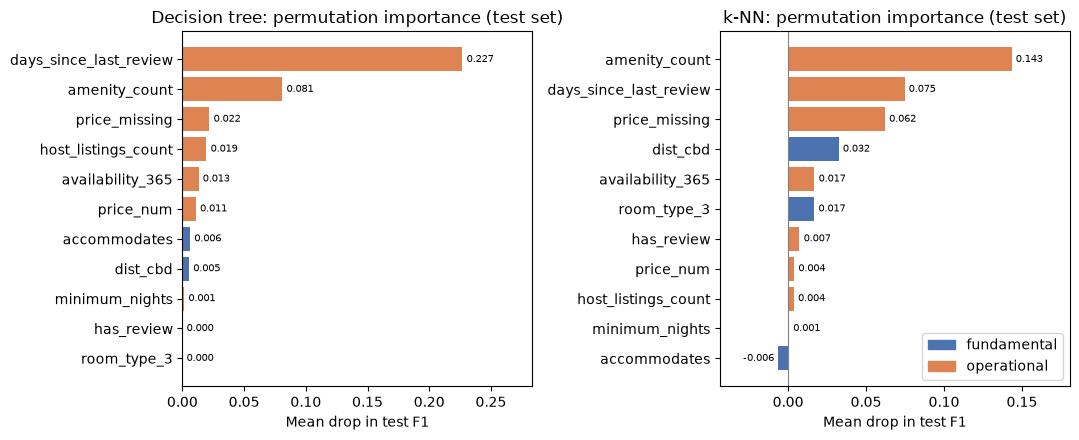

In [ ]:
final_tree_pipeline = final_models["DT"]
transformed_feature_names = final_tree_pipeline.named_steps["prep"].get_feature_names_out()
# Impurity importance of the tuned tree (training set). The three one-hot room_type columns
# are summed back into one feature, so the 11 values still sum to 1. This is the embedded
# feature-selection score used in the feature-selection section of the report.
tree_builtin_importance = (
    pd.Series(
        final_tree_pipeline.named_steps["model"].feature_importances_,
        index=["room_type_3" if name.startswith("cat__") else name[5:] for name in transformed_feature_names],
    )
    .groupby(level=0)
    .sum()
)

# Impurity importance exists only for the tree; k-NN has none. Permutation importance
# (shuffle one column of the test set, measure the mean drop in F1 over 10 shuffles) works
# for any model, so it puts both models on the same scale for the question "do they rely on
# the same inputs?". The whole pipeline is passed, so room_type_3 is shuffled as one column.
# Caveat: correlated features cover for each other (shuffling days_since_last_review leaves
# has_review intact), so a low score does not prove a feature carries no information.
permutation_importance_by_model = {
    model_name: pd.Series(
        permutation_importance(final_models[model_name], X_test, y_test, scoring="f1", n_repeats=10, random_state=RANDOM_SEED, n_jobs=-1).importances_mean,
        index=ALL_FEATURES,
    )
    for model_name in ("KNN", "DT")
}

feature_ranking_table = pd.DataFrame(
    {
        "group": ["fundamental" if column in fundamentals else "operational" for column in ALL_FEATURES],
        "DT_builtin": tree_builtin_importance,
        "DT_perm": permutation_importance_by_model["DT"],
        "KNN_perm": permutation_importance_by_model["KNN"],
    },
    index=ALL_FEATURES,
)
evidence["permutation_importance"] = {model_name: scores.round(4).to_dict() for model_name, scores in permutation_importance_by_model.items()}

# Separate groups via distinct colors
GROUP_COLORS = {"fundamental": "#4C72B0", "operational": "#DD8452"}

# Two panels on the same scale (drop in test F1), one per model
figure, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for axis, column, title in [(axes[0], "DT_perm", "Decision tree"), (axes[1], "KNN_perm", "k-NN")]:
    sorted_table = feature_ranking_table.sort_values(column)
    importance_bars = axis.barh(sorted_table.index, sorted_table[column], color=sorted_table["group"].map(GROUP_COLORS))
    axis.bar_label(importance_bars, labels=[f"{value:.3f}" for value in sorted_table[column]], padding=3, fontsize=7)
    # A small negative value means shuffling happened to help slightly, i.e. the feature is unused
    axis.axvline(0, color="grey", linewidth=0.8)
    # Headroom so the labels on the longest bars are not clipped
    axis.margins(x=0.25)
    axis.set(title=f"{title}: permutation importance (test set)", xlabel="Mean drop in test F1")
axes[1].legend(handles=[Patch(color=color, label=group) for group, color in GROUP_COLORS.items()], loc="lower right")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "fig_importance.png"), dpi=150)
plt.close(figure)

print(feature_ranking_table.round(4).to_string())
figure

### 3.7 Feature selection

In [ ]:
X_train_for_mutual_info = X_train.copy()  # Copy of training data
X_train_for_mutual_info["room_type_3"] = X_train_for_mutual_info["room_type_3"].astype("category").cat.codes
X_train_for_mutual_info = X_train_for_mutual_info.fillna(X_train_for_mutual_info.median())
# mutual_info_classif returns nats; dividing by ln 2 puts the score in bits, the unit used
# in the correlation table and quoted in the report.
feature_ranking_table["filter_MI"] = mutual_info_classif(
    X_train_for_mutual_info,
    y_train,
    random_state=RANDOM_SEED,
    discrete_features=[column in ("room_type_3", "has_review", "price_missing") for column in ALL_FEATURES],
) / np.log(2)

# Filter rank: MI scores each feature against y on its own, so redundant features
# (e.g. availability_365 and days_since_last_review) can both rank high.
# Embedded rank: impurity importance only credits what a feature adds after earlier
# splits, so the second of two redundant features is pushed down.
feature_ranking_table["filter_rank"] = feature_ranking_table["filter_MI"].rank(ascending=False, method="min").astype(int)
feature_ranking_table["embedded_rank"] = feature_ranking_table["DT_builtin"].rank(ascending=False, method="min").astype(int)
top3_features = {
    "filter_top3": feature_ranking_table["filter_MI"].nlargest(3).index.tolist(),
    "embedded_top3": feature_ranking_table["DT_builtin"].nlargest(3).index.tolist(),
}

evidence["top3"] = top3_features
evidence["top3_common"] = sorted(set(top3_features["filter_top3"]) & set(top3_features["embedded_top3"]))
evidence["feature_ranking"] = feature_ranking_table.round(4).to_dict("index")

print("\n", feature_ranking_table.sort_values("filter_rank").round(4).to_string())
top3_features


                               group  DT_builtin  DT_perm  KNN_perm  filter_MI  filter_rank  embedded_rank
days_since_last_review  operational      0.5005   0.2269    0.0747     0.1837            1              1
host_listings_count     operational      0.2698   0.0195    0.0037     0.1569            2              2
availability_365        operational      0.0356   0.0131    0.0169     0.1095            3              4
amenity_count           operational      0.1023   0.0810    0.1433     0.1080            4              3
price_num               operational      0.0277   0.0109    0.0039     0.0948            5              6
price_missing           operational      0.0024   0.0219    0.0621     0.0651            6              9
has_review              operational      0.0000   0.0000    0.0073     0.0496            7             11
dist_cbd                fundamental      0.0278   0.0054    0.0324     0.0490            8              5
minimum_nights          operational      0.0

{'filter_top3': ['days_since_last_review',
  'host_listings_count',
  'availability_365'],
 'embedded_top3': ['days_since_last_review',
  'host_listings_count',
  'amenity_count']}

### 3.8 Hard-case analysis

In [ ]:
test_detail_table = X_test.assign(
    y_true=y_test,
    y_pred=test_predictions[best_model_name],
    proba=final_models[best_model_name].predict_proba(X_test)[:, 1],
    id=listings.loc[X_test.index, "id"],
    host_id=host_ids_test,
)
# All superhosts the tree missed, most confident miss first (stable sort keeps ties reproducible)
false_negatives = test_detail_table[(test_detail_table["y_true"] == 1) & (test_detail_table["y_pred"] == 0)].sort_values("proba", kind="stable")
hard_case = false_negatives.iloc[0]

median_comparison_table = X_train.groupby(y_train).median(numeric_only=True).T
median_comparison_table.columns = ["non_superhost_median", "superhost_median"]
median_comparison_table["this_listing"] = hard_case[median_comparison_table.index].astype(float)

hard_case_host_listings = listings[listings["host_id"] == hard_case["host_id"]]
evidence["hard_case"] = {
    "listing_id": int(hard_case["id"]),
    "host_id": int(hard_case["host_id"]),
    "model": best_model_name,
    "proba_superhost": round_value(hard_case["proba"]),
    "room_type": hard_case["room_type_3"],
    "fn_total": len(false_negatives),
    "listing_number_of_reviews": int(listings.loc[hard_case.name, "number_of_reviews"]),
    "host_n_listings": len(hard_case_host_listings),
    "host_listings_with_reviews": int(hard_case_host_listings["has_review"].sum()),
    "comparison": median_comparison_table.round(2).to_dict("index"),
}
print("\n", {key: value for key, value in evidence["hard_case"].items() if key != "comparison"}, "\n", median_comparison_table.round(2))

inactive_over_year = test_detail_table["days_since_last_review"] > 365
evidence["false_negative_context"] = {
    "test_superhosts_inactive_over_year": int((inactive_over_year & (test_detail_table["y_true"] == 1)).sum()),
    "false_negatives_inactive_over_year": int(inactive_over_year[false_negatives.index].sum()),
    # Both feature-selection methods rank days_since_last_review first. A value can be ordinary
    # among all listings yet extreme within its own class: the two percentiles below show where
    # the hard case sits on the top-ranked feature (computed on the training set).
    "hard_case_dsl_percentile_among_all_listings": round_value((X_train["days_since_last_review"] < hard_case["days_since_last_review"]).mean() * 100, 1),
    "hard_case_dsl_percentile_among_reviewed_superhosts": round_value(
        (X_train.loc[(y_train == 1) & (X_train["has_review"] == 1), "days_since_last_review"] < hard_case["days_since_last_review"]).mean() * 100, 1
    ),
}
print("false negative context:", evidence["false_negative_context"])


 {'listing_id': 6812677, 'host_id': 35667203, 'model': 'DT', 'proba_superhost': 0.0, 'room_type': 'Entire home/apt', 'fn_total': 530, 'listing_number_of_reviews': 195, 'host_n_listings': 1, 'host_listings_with_reviews': 1} 
                         non_superhost_median  superhost_median  this_listing
dist_cbd                                4.92              4.64          3.71
accommodates                            3.00              4.00          4.00
availability_365                      124.00            195.00        116.00
amenity_count                          32.00             45.00         18.00
days_since_last_review                468.00             37.00        156.00
has_review                              1.00              1.00          1.00
price_num                             240.00            252.00        261.00
price_missing                           0.00              0.00          0.00
minimum_nights                          2.00              2.00          2.00
host

### 3.8b Why the tree misses the hard case

In [ ]:
# Follow the hard case through the tuned tree, node by node, to the leaf that produces its
# probability. Also record the k-NN prediction and two of the EXCLUDED criteria columns,
# which are used only to explain the case, never as model inputs.
tree_model = final_models["DT"].named_steps["model"]
hard_case_row = X_test.loc[[hard_case.name]]
transformed_row = final_models["DT"].named_steps["prep"].transform(hard_case_row)
tree_path = []
for node in tree_model.decision_path(transformed_row).indices:
    if tree_model.tree_.children_left[node] == -1:
        leaf_values = tree_model.tree_.value[node][0]
        tree_path.append({"leaf": int(node), "training_listings": int(tree_model.tree_.n_node_samples[node]), "superhost_share": round_value(leaf_values[1] / leaf_values.sum())})
    else:
        feature_position = tree_model.tree_.feature[node]
        feature_name = transformed_feature_names[feature_position]
        value, threshold = transformed_row[0, feature_position], tree_model.tree_.threshold[node]
        tree_path.append(
            {
                "feature": "room_type_3" if feature_name.startswith("cat__") else feature_name[5:],
                "value": round_value(value, 2),
                "rule": "<=" if value <= threshold else ">",
                "threshold": round_value(threshold, 2),
            }
        )
evidence["hard_case"]["tree_path"] = tree_path
evidence["hard_case"]["knn_proba_superhost"] = round_value(final_models["KNN"].predict_proba(hard_case_row)[0, 1])
evidence["hard_case"]["number_of_reviews_ltm"] = int(listings.loc[hard_case.name, "number_of_reviews_ltm"])
evidence["hard_case"]["review_scores_rating"] = round_value(listings.loc[hard_case.name, "review_scores_rating"], 2)
pd.DataFrame(tree_path)

,feature,value,rule,threshold,leaf,training_listings,superhost_share
0,days_since_last_review,156.0,>,147.50,NaN,NaN,NaN
1,host_listings_count,1.0,<=,1.50,NaN,NaN,NaN
2,days_since_last_review,156.0,<=,386.50,NaN,NaN,NaN
3,amenity_count,18.0,<=,51.50,NaN,NaN,NaN
4,amenity_count,18.0,<=,26.50,NaN,NaN,NaN
5,price_num,261.0,>,77.81,NaN,NaN,NaN
6,minimum_nights,2.0,<=,18.00,NaN,NaN,NaN
7,days_since_last_review,156.0,>,152.50,NaN,NaN,NaN
8,availability_365,116.0,>,1.00,NaN,NaN,NaN
9,amenity_count,18.0,<=,24.50,NaN,NaN,NaN


In [ ]:
# Tables
tuning_table.round(4).to_csv(OUTPUT_DIR / "cv_results.csv", index=False)
rq_experiment_table.round(4).to_csv(OUTPUT_DIR / "rq_experiments.csv", index=False)
feature_ranking_table.round(4).to_csv(OUTPUT_DIR / "feature_ranking.csv")

with open(os.path.join(OUTPUT_DIR, "evidence_model.json"), "w") as evidence_file:
    json.dump(evidence, evidence_file, indent=2, ensure_ascii=False, default=str)

## Part 4: PCA and clustering

Input: `data/clean.parquet` (reviewed listings only).  
Outputs: `outputs/evidence_cluster.json`, `outputs/pca_table.csv`, `outputs/cluster_profiles.csv`, `outputs/fig_elbow.png`, `outputs/fig_pca_clusters.png`, `outputs/fig_dendrogram.png`.  
Cluster labels are 0-based here; the report numbers them 1–5 (label + 1).

In [ ]:
N_CLUSTERS_RANGE = range(2, 9)
FIGURE_SAMPLE_SIZE = 5000
DENDROGRAM_SAMPLE_SIZE = 2000

evidence = {}

# Listings dataframe (reloaded; the reviewed-only filter is applied in 4.1)
listings = pd.read_parquet(DATA_DIR / "clean.parquet")

### 4.1 Data


In [ ]:
# Clustering covers reviewed listings only. The 4,477 zero-review listings all share the
# artificial fill value 4,594 for days_since_last_review, so they would collapse into a
# fake cluster that describes the imputation rather than the listings.
listings_reviewed = listings[listings["has_review"] == 1].copy()

evidence["n_rows_full"] = len(listings)
evidence["n_hosts_full"] = listings["host_id"].nunique()
evidence["superhost_rate_full"] = round_value(listings["y"].mean())
evidence["n_rows_reviewed"] = len(listings_reviewed)
evidence["n_hosts_reviewed"] = listings_reviewed["host_id"].nunique()
evidence["superhost_rate_reviewed"] = round_value(listings_reviewed["y"].mean())

### 4.2 Feature sets


In [ ]:
# Three candidate feature sets. S3 is used: only a set holding both families lets the PCA
# loadings and cluster centres show which family the data's main structure runs along.
FUNDAMENTAL_FEATURES = ["dist_cbd", "accommodates"]
OPERATIONAL_FEATURES = ["availability_365", "amenity_count", "days_since_last_review", "host_listings_count"]
CANDIDATE_FEATURE_SETS = {
    "S1_operational_only": OPERATIONAL_FEATURES,
    "S2_fundamentals_only": FUNDAMENTAL_FEATURES,
    "S3_mixed": FUNDAMENTAL_FEATURES + OPERATIONAL_FEATURES,
}
CLUSTER_FEATURES = CANDIDATE_FEATURE_SETS["S3_mixed"]
LOG_FEATURES = ["days_since_last_review", "host_listings_count", "dist_cbd"]

clustering_input = listings_reviewed[CLUSTER_FEATURES].copy()

# Evidence for the feature-set choice and for the exclusions
evidence["candidate_feature_sets"] = {name: columns for name, columns in CANDIDATE_FEATURE_SETS.items()}
evidence["max_before_log"] = {column: round_value(clustering_input[column].max(), 2) for column in CLUSTER_FEATURES}

### 4.3 Preprocessing


In [ ]:
# Log transform the three skewed features: PCA and K-Means are driven by variance and
# distance, so a single maximum of 667 listings would dominate the first component.
# log1p rather than log: days_since_last_review reaches 0.
log_transformed = clustering_input.copy()
for column in LOG_FEATURES:
    log_transformed[column] = np.log1p(log_transformed[column])

# Standardise all features, availability_365 (0-365) > accommodates (1-16)
scaler = StandardScaler()
scaled_features = pd.DataFrame(
    scaler.fit_transform(log_transformed),
    columns=CLUSTER_FEATURES,
    index=log_transformed.index,
)

# Every column should be centred and unit-scaled
evidence["scaled_mean_abs_max"] = round_value(scaled_features.mean().abs().max(), 6)
evidence["scaled_std_min"] = round_value(scaled_features.std(ddof=0).min())

### 4.4 PCA


In [ ]:
pca = PCA()
principal_components = pca.fit_transform(scaled_features)
explained_variance = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

evidence["n_components"] = int(len(explained_variance))
evidence["explained_variance_first3"] = [round_value(value) for value in explained_variance[:3]]
evidence["cumulative_variance_first3"] = [round_value(value) for value in cumulative_variance[:3]]

# For each of the first three components, the three features with the largest loadings
# by absolute value. The signs are kept: a component can be flipped as a whole, so what
# matters is which features share a sign and which oppose.
pca_rows = []
for component_index in range(3):
    loadings = pd.Series(pca.components_[component_index], index=CLUSTER_FEATURES)
    top_loadings = loadings.reindex(loadings.abs().sort_values(ascending=False).index)[:3]
    row = {
        "component": f"PC{component_index + 1}",
        "explained_variance": round_value(explained_variance[component_index]),
        "cumulative_variance": round_value(cumulative_variance[component_index]),
    }
    for rank, (feature, value) in enumerate(top_loadings.items(), start=1):
        row[f"loading_{rank}_feature"] = feature
        row[f"loading_{rank}_value"] = round_value(value, 3)
    pca_rows.append(row)
pca_table = pd.DataFrame(pca_rows)

evidence["pca_top_loadings"] = {row["component"]: [[row[f"loading_{rank}_feature"], row[f"loading_{rank}_value"]] for rank in (1, 2, 3)] for row in pca_rows}

pca_table

,component,explained_variance,cumulative_variance,loading_1_feature,loading_1_value,loading_2_feature,loading_2_value,loading_3_feature,loading_3_value
0,PC1,0.3211,0.3211,days_since_last_review,0.563,amenity_count,-0.504,availability_365,-0.447
1,PC2,0.2045,0.5255,dist_cbd,0.786,host_listings_count,-0.556,accommodates,0.208
2,PC3,0.1681,0.6936,accommodates,0.671,availability_365,-0.591,amenity_count,0.355


### 4.4b Components vs superhost status

In [ ]:
# How strongly is each component associated with superhost status? Point-biserial r, and NMI
# after 10 equal-frequency bins (the same binning as Part 2). y is used only to describe the
# components; it is not an input to PCA. A component can explain much variance yet carry
# little information about the target.
pc_vs_superhost = {}
for component_index in range(3):
    component_scores = principal_components[:, component_index]
    pc_vs_superhost[f"PC{component_index + 1}"] = {
        "point_biserial_r": round_value(np.corrcoef(component_scores, listings_reviewed["y"])[0, 1], 3),
        "nmi_10_bins": round_value(normalized_mutual_info_score(pd.qcut(component_scores, 10, labels=False), listings_reviewed["y"])),
    }
evidence["pc_vs_superhost"] = pc_vs_superhost
pd.DataFrame(pc_vs_superhost).T

,point_biserial_r,nmi_10_bins
PC1,-0.354,0.0570
PC2,0.050,0.0036
PC3,-0.058,0.0037


### 4.5 K-Means


Chosen k= 5
 k        sse  silhouette_5000_sample  sse_drop_pct
 2 99719.9895                  0.2140           NaN
 3 83737.5673                  0.2178          16.0
 4 72991.5226                  0.2227          12.8
 5 64211.4457                  0.2232          12.0
 6 59864.5843                  0.2177           6.8
 7 56113.1695                  0.1995           6.3
 8 53229.2371                  0.1937           5.1


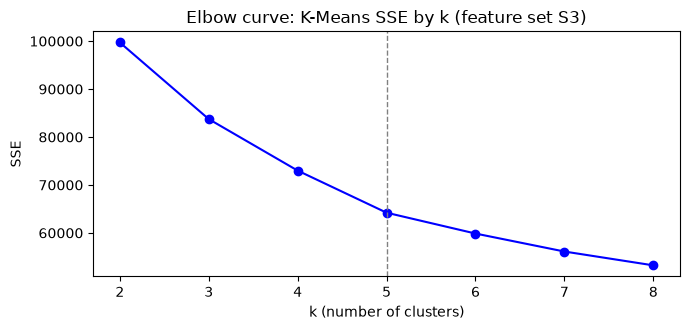

In [ ]:
# Fit K-Means once per candidate k.
# SSE (sum of squared errors, sklearn's inertia_) = the sum of squared distances from each
# listing to its own cluster centre.
sse_values = []
for k in N_CLUSTERS_RANGE:
    kmeans = KMeans(n_clusters=k, n_init=10, random_state=RANDOM_SEED)
    kmeans.fit(scaled_features)
    sse_values.append(kmeans.inertia_)

kmeans_sweep = pd.DataFrame({"k": list(N_CLUSTERS_RANGE), "sse": sse_values})
# Relative drop in SSE from k-1 to k: the elbow is where this drop falls off
kmeans_sweep["sse_drop_pct"] = (-kmeans_sweep["sse"].pct_change() * 100).round(1)
evidence["kmeans_sweep"] = kmeans_sweep.round(DEFAULT_ROUNDING_DECIMALS).to_dict("records")

# k is chosen from the SSE curve below (the drop halves after k = 5: 12.0% -> 6.8%)
CHOSEN_K = 5

# Elbow plot
figure, axis = plt.subplots(figsize=(7, 3.4))
axis.plot(kmeans_sweep["k"], kmeans_sweep["sse"], "bo-")
axis.axvline(CHOSEN_K, color="grey", linestyle="--", linewidth=1)
axis.set(title="Elbow curve: K-Means SSE by k (feature set S3)", xlabel="k (number of clusters)", ylabel="SSE")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "fig_elbow.png", dpi=150)
plt.close(figure)

evidence["chosen_k"] = CHOSEN_K
evidence["chosen_k_sse"] = round_value(kmeans_sweep.loc[kmeans_sweep["k"] == CHOSEN_K, "sse"].iloc[0], 1)

kmeans_final = KMeans(n_clusters=CHOSEN_K, n_init=10, random_state=RANDOM_SEED)
kmeans_labels = kmeans_final.fit_predict(scaled_features)

evidence["kmeans_sizes"] = {int(k): int(v) for k, v in pd.Series(kmeans_labels).value_counts().sort_index().items()}  # ty:ignore[invalid-argument-type]
print("Chosen k=", CHOSEN_K)
print(kmeans_sweep.round(4).to_string(index=False))
figure

### 4.5b Comparing the three candidate feature sets


In [ ]:
# The same pipeline (log1p on skewed columns, standardise, K-Means with the chosen k) is run
# on each candidate set, so the comparison is like for like. Two numbers per set:
#   superhost_rate_spread  max - min superhost rate across clusters (y is used only to
#                          DESCRIBE the clusters, never as a clustering input)
#   smallest_cluster_size  flags degenerate clusters
def scale_feature_set(columns):
    """Same transform as the final set: log1p on skewed columns, then standardise."""
    frame = listings_reviewed[columns].copy()
    for column in columns:
        if column in LOG_FEATURES:
            frame[column] = np.log1p(frame[column])
    return StandardScaler().fit_transform(frame)


candidate_comparison = {}
for set_name, columns in CANDIDATE_FEATURE_SETS.items():
    scaled_candidate = scale_feature_set(columns)
    candidate_labels = KMeans(n_clusters=CHOSEN_K, n_init=10, random_state=RANDOM_SEED).fit_predict(scaled_candidate)
    rates_by_cluster = listings_reviewed["y"].groupby(candidate_labels).mean()
    candidate_comparison[set_name] = {
        "n_features": len(columns),
        "superhost_rate_spread": round_value(rates_by_cluster.max() - rates_by_cluster.min()),
        "smallest_cluster_size": int(np.bincount(candidate_labels).min()),
    }
evidence["candidate_set_comparison"] = candidate_comparison
pd.DataFrame(candidate_comparison).T

,n_features,superhost_rate_spread,smallest_cluster_size,silhouette_5000_sample
S1_operational_only,4.0,0.5331,3243.0,0.2942
S2_fundamentals_only,2.0,0.0754,780.0,0.3997
S3_mixed,6.0,0.4719,2365.0,0.2232


### 4.6 Hierarchical


In [ ]:
# Both methods to use the same k, which is passed in as n_clusters.
# Ward merges the pair of clusters that adds the least within-cluster variance, which is
# the same quantity K-Means minimises.
hierarchical_model = AgglomerativeClustering(n_clusters=CHOSEN_K, linkage="ward")
hierarchical_labels = hierarchical_model.fit_predict(scaled_features)

evidence["hierarchical_sizes"] = {int(k): int(v) for k, v in pd.Series(hierarchical_labels).value_counts().sort_index().items()}
evidence["hierarchical_clusters_returned"] = int(pd.Series(hierarchical_labels).nunique())

### 4.6b Why Ward linkage

In [ ]:
# The lectures cover single, complete and average linkage. Each is run on the same scaled
# features with the same k. On this data they collapse most listings into one cluster
# (single linkage chains; average and complete are dominated by a few far-out listings),
# so their clusters cannot describe the market. Ward merges the pair of clusters with the
# smallest increase in within-cluster SSE, the quantity K-Means minimises, so the two
# methods are compared on the same criterion.
linkage_comparison_sizes = {}
for linkage_name in ("single", "complete", "average"):
    linkage_labels = AgglomerativeClustering(n_clusters=CHOSEN_K, linkage=linkage_name).fit_predict(scaled_features)
    linkage_comparison_sizes[linkage_name] = sorted(np.bincount(linkage_labels).tolist(), reverse=True)
linkage_comparison_sizes["ward"] = sorted(evidence["hierarchical_sizes"].values(), reverse=True)
evidence["linkage_comparison_sizes"] = linkage_comparison_sizes
pd.DataFrame(linkage_comparison_sizes, index=[f"cluster {rank}" for rank in range(1, CHOSEN_K + 1)])

,single,complete,average,ward
cluster 1,21247,12473,19482,8256
cluster 2,1,5425,1401,4716
cluster 3,1,2453,341,3829
cluster 4,1,562,26,3249
cluster 5,1,338,1,1201


### 4.7 Comparing the two methods


In [ ]:
# Cluster numbering is arbitrary, so the comparison runs through the cross-tabulation
# rather than through the labels themselves. The crosstab and the size columns are the
# evidence: they show which clusters correspond one-to-one and which are split.
cluster_crosstab = pd.crosstab(
    pd.Series(kmeans_labels, name="kmeans_cluster"),
    pd.Series(hierarchical_labels, name="hierarchical_cluster"),
)

# orient="index" gives {kmeans cluster: {hierarchical cluster: count}}, matching the
# printed table. The default orient is dict-of-columns, which nests it the other way up.
evidence["crosstab"] = {str(k): {str(k2): int(v) for k2, v in row.items()} for k, row in cluster_crosstab.to_dict(orient="index").items()}

# Majority overlap = share of listings that sit in the Ward cluster most common within their
# K-Means cluster. It complements the crosstab, which shows WHERE the methods differ.
evidence["kmeans_vs_hierarchical_majority_overlap"] = round_value(cluster_crosstab.max(axis=1).sum() / len(kmeans_labels))
print("majority overlap:", evidence["kmeans_vs_hierarchical_majority_overlap"])
cluster_crosstab

ARI: 0.3766 | majority overlap: 0.6842


hierarchical_cluster,0,1,2,3,4
kmeans_cluster,,,,,
0,119,609,3696,0,117
1,4410,507,409,2,12
2,815,549,100,3224,1
3,1099,54,199,2,1011
4,1813,2110,312,21,60


### 4.8 Cluster profiles


In [ ]:
def build_cluster_profiles(labels, method_name):
    """Median of each clustering feature in original units, plus the superhost rate."""
    frame = listings_reviewed.assign(cluster=labels)
    profiles = frame.groupby("cluster").agg(
        listings=("cluster", "size"),
        superhost_rate=("y", "mean"),
        **{column: (column, "median") for column in CLUSTER_FEATURES},
    )
    profiles.insert(0, "method", method_name)
    profiles.insert(2, "share", profiles["listings"] / len(frame))
    return profiles.round(DEFAULT_ROUNDING_DECIMALS)


cluster_profiles = pd.concat(
    [
        build_cluster_profiles(kmeans_labels, "KMeans"),
        build_cluster_profiles(hierarchical_labels, "Hierarchical"),
    ]
).reset_index(names="cluster")

# y appears for the first time here, and only to describe the clusters
evidence["cluster_profiles"] = cluster_profiles.to_dict("records")
evidence["kmeans_superhost_rate_spread"] = round_value(cluster_profiles.query("method == 'KMeans'")["superhost_rate"].max() - cluster_profiles.query("method == 'KMeans'")["superhost_rate"].min())
evidence["hierarchical_superhost_rate_spread"] = round_value(
    cluster_profiles.query("method == 'Hierarchical'")["superhost_rate"].max() - cluster_profiles.query("method == 'Hierarchical'")["superhost_rate"].min()
)

cluster_profiles

,cluster,method,listings,share,superhost_rate,dist_cbd,accommodates,availability_365,amenity_count,days_since_last_review,host_listings_count
0,0,KMeans,4541,0.2137,0.3532,1.4173,4.0,188.0,41.0,50.0,50.0
1,1,KMeans,5340,0.2513,0.5395,2.2476,4.0,157.0,47.0,40.0,2.0
2,2,KMeans,4689,0.2206,0.0676,4.5432,2.0,0.0,23.0,1883.0,1.0
3,3,KMeans,2365,0.1113,0.4368,20.5645,8.0,218.0,51.0,58.0,3.0
4,4,KMeans,4316,0.2031,0.4066,17.8220,2.0,310.0,33.0,76.0,2.0
5,0,Hierarchical,8256,0.3885,0.4994,5.3612,4.0,174.0,47.0,56.0,1.0
6,1,Hierarchical,3829,0.1802,0.3014,7.3218,2.0,267.0,22.0,100.0,3.0
7,2,Hierarchical,4716,0.2219,0.3745,1.7915,4.0,175.0,42.0,55.0,45.0
8,3,Hierarchical,3249,0.1529,0.0286,4.3434,2.0,0.0,20.0,2364.0,1.0
9,4,Hierarchical,1201,0.0565,0.3780,17.5486,10.0,221.0,49.0,49.0,12.0


### 4.9 Figures


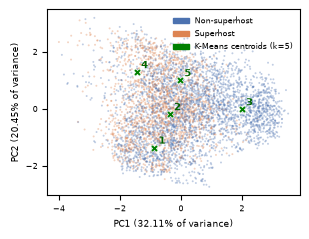

In [ ]:
# Dendrogram
dendrogram_sample = scaled_features.sample(DENDROGRAM_SAMPLE_SIZE, random_state=RANDOM_SEED)
figure, axis = plt.subplots(figsize=(9, 4.5))
dendrogram(linkage(dendrogram_sample.to_numpy(), method="ward"), truncate_mode="lastp", p=30, ax=axis, no_labels=True)
axis.set(title=f"Ward dendrogram (n={DENDROGRAM_SAMPLE_SIZE}, k={CHOSEN_K})", ylabel="Merge distance")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "fig_dendrogram.png", dpi=150)
plt.close(figure)

# PCA Scatterplot
STATUS_COLOURS = {"Non-superhost": "#4C72B0", "Superhost": "#DD8452"}
sample_positions = np.random.default_rng(RANDOM_SEED).choice(len(principal_components), min(FIGURE_SAMPLE_SIZE, len(principal_components)), replace=False)
scatter_frame = pd.DataFrame(
    {
        "PC1": principal_components[sample_positions, 0],
        "PC2": principal_components[sample_positions, 1],
        "Status": np.where(listings_reviewed["y"].to_numpy()[sample_positions] == 1, "Superhost", "Non-superhost"),
    }
)
centres_in_pc_space = pca.transform(pd.DataFrame(kmeans_final.cluster_centers_, columns=CLUSTER_FEATURES))

# Sized for the report: 2.95 x 2.25 inches inserted at 100% (the caption carries the title)
with plt.rc_context({"font.size": 6.5, "axes.labelsize": 6.5, "xtick.labelsize": 6, "ytick.labelsize": 6}):
    figure, axis = plt.subplots(figsize=(2.95, 2.25))
    sns.scatterplot(data=scatter_frame, x="PC1", y="PC2", hue="Status", palette=STATUS_COLOURS, s=2, alpha=0.35, linewidth=0, legend=False, ax=axis)
    sns.scatterplot(x=centres_in_pc_space[:, 0], y=centres_in_pc_space[:, 1], marker="X", s=28, color="green", ax=axis)
    # Number the centroids as in the report (cluster label + 1)
    for cluster_label, (pc1_score, pc2_score) in enumerate(centres_in_pc_space[:, :2]):
        axis.annotate(str(cluster_label + 1), (pc1_score, pc2_score), xytext=(3, 3), textcoords="offset points", fontsize=7, fontweight="bold", color="darkgreen")
    axis.set(xlabel=f"PC1 ({explained_variance[0] * 100:.2f}% of variance)", ylabel=f"PC2 ({explained_variance[1] * 100:.2f}% of variance)")
    axis.legend(
        handles=[Patch(color=colour, label=status) for status, colour in STATUS_COLOURS.items()] + [Patch(color="green", label=f"K-Means centroids (k={CHOSEN_K})")],
        loc="upper right",
        fontsize=5.5,
        frameon=False,
    )
    plt.tight_layout(pad=0.3)
    plt.savefig(OUTPUT_DIR / "fig_pca_clusters.png", dpi=300)
    plt.close(figure)

figure

### 4.10 Save


In [ ]:
# Checks before saving
assert len(listings_reviewed) == evidence["n_rows_reviewed"]
assert scaled_features.notna().all().all()
assert evidence["n_components"] == len(CLUSTER_FEATURES)
assert evidence["hierarchical_clusters_returned"] == CHOSEN_K
assert len(dendrogram_sample) == DENDROGRAM_SAMPLE_SIZE

pca_table.to_csv(OUTPUT_DIR / "pca_table.csv", index=False)
cluster_profiles.round(DEFAULT_ROUNDING_DECIMALS).to_csv(OUTPUT_DIR / "cluster_profiles.csv", index=False)
with open(OUTPUT_DIR / "evidence_cluster.json", "w") as evidence_file:
    json.dump(evidence, evidence_file, indent=2, ensure_ascii=False, default=str)

print(f"rows clustered        : {len(scaled_features):,}")
print(f"chosen k              : {CHOSEN_K}")
print(f"PC1 / PC2 variance    : {explained_variance[0] * 100:.1f}% / {explained_variance[1] * 100:.1f}%")

rows clustered        : 21,251
chosen k              : 5
PC1 / PC2 variance    : 32.1% / 20.4%
